# 02 — The Surrogate Architecture

Phase 2 builds the network that Phase 3 will train and Phase 5 will invert. The spec calls
out three architectural choices that each do real, load-bearing work — this notebook
demonstrates *why* for each, rather than just asserting it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from graydiff.model import CircularConv2d, Surrogate, make_input
from graydiff.solver import standard_seed, rollout
from graydiff.constants import SPOTS_CHECKPOINT

plt.rcParams["figure.facecolor"] = "white"
torch.manual_seed(0)


In [2]:
model = Surrogate(hidden=64)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")

x = torch.randn(4, 4, 64, 64)
y = model(x)
print(f"\nInput shape:  {tuple(x.shape)}  (U, V, F_grid, k_grid)")
print(f"Output shape: {tuple(y.shape)}  (U_next, V_next)")

Surrogate(
  (net): Sequential(
    (0): CircularConv2d(
      (conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (1): GELU(approximate='none')
    (2): CircularConv2d(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (3): GELU(approximate='none')
    (4): CircularConv2d(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (5): GELU(approximate='none')
    (6): CircularConv2d(
      (conv): Conv2d(64, 2, kernel_size=(3, 3), stride=(1, 1))
    )
  )
)

Total parameters: 77,378

Input shape:  (4, 4, 64, 64)  (U, V, F_grid, k_grid)
Output shape: (4, 2, 64, 64)  (U_next, V_next)


## 1. Circular padding — why it has to match the solver's boundary condition

`graydiff.solver.laplacian` wraps around the grid edges (`np.roll`). If the surrogate's
convolutions instead used ordinary zero-padding, every pixel near the boundary would see a
fabricated "wall" of zeros that doesn't exist in the real system — the model would learn
edge physics that isn't real. Demonstrate directly: run a real Gray-Scott field (which is
seamless across its periodic boundary by construction) through a random-init conv with
circular padding vs. zero padding, and look at what happens right at the edge.

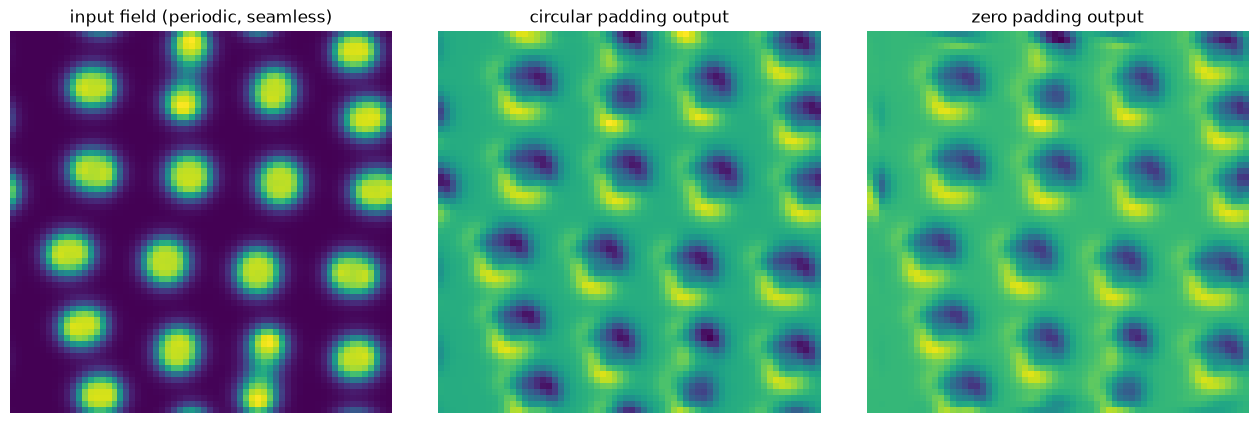

Mean |top row - bottom row| after circular-pad conv: 0.02108
Mean |top row - bottom row| after zero-pad conv:     0.05760

The input field is periodic, so a boundary-correct filter should treat top/bottom
(and left/right) edges as neighbours -- circular padding does; zero padding introduces
a visible seam because it convolves against a fictitious wall of zeros instead.


In [3]:
U, V = standard_seed(64, 64)
_, Vf, _ = rollout(U, V, n_steps=6000, F=SPOTS_CHECKPOINT["F"], k=SPOTS_CHECKPOINT["k"])
field = torch.from_numpy(Vf).float()[None, None]  # [1,1,64,64]

circular = CircularConv2d(1, 1, kernel_size=5)
zero_pad = nn.Conv2d(1, 1, 5, padding=2, padding_mode="zeros")
with torch.no_grad():
    zero_pad.weight.copy_(circular.conv.weight)
    zero_pad.bias.copy_(circular.conv.bias)

with torch.no_grad():
    out_circular = circular(field)[0, 0].numpy()
    out_zero = zero_pad(field)[0, 0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].imshow(Vf, cmap="viridis"); axes[0].set_title("input field (periodic, seamless)")
axes[1].imshow(out_circular, cmap="viridis"); axes[1].set_title("circular padding output")
axes[2].imshow(out_zero, cmap="viridis"); axes[2].set_title("zero padding output")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/02_padding_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

edge_diff_circular = np.abs(out_circular[0, :] - out_circular[-1, :]).mean()
edge_diff_zero = np.abs(out_zero[0, :] - out_zero[-1, :]).mean()
print(f"Mean |top row - bottom row| after circular-pad conv: {edge_diff_circular:.5f}")
print(f"Mean |top row - bottom row| after zero-pad conv:     {edge_diff_zero:.5f}")
print("\nThe input field is periodic, so a boundary-correct filter should treat top/bottom")
print("(and left/right) edges as neighbours -- circular padding does; zero padding introduces")
print("a visible seam because it convolves against a fictitious wall of zeros instead.")

## 2. Translation-equivariance as a correctness check

A boundary-correct, spatially-invariant filter should commute with a periodic shift of its
input: `conv(roll(x)) == roll(conv(x))`. This is exactly what `tests/test_model.py` checks
(`test_circular_padding_translation_equivariance`, `test_full_model_translation_equivariance`)
— reproduced here for visibility.

In [4]:
shift = (17, -9)
with torch.no_grad():
    y1 = model(x)
    y2 = model(torch.roll(x, shifts=shift, dims=(2, 3)))
mismatch = (torch.roll(y1, shifts=shift, dims=(2, 3)) - y2).abs().max().item()
print(f"max |roll(model(x)) - model(roll(x))| = {mismatch:.2e}  (should be ~0)")

max |roll(model(x)) - model(roll(x))| = 0.00e+00  (should be ~0)


## 3. Residual output — predicting the delta, not the whole frame

Notebook 01 measured the actual per-step change directly from real trajectories: the
per-step |delta V| is small relative to V's [0, 1] range (a Gray-Scott step is a gentle
nudge, not a repaint). The architecture is built to exploit that: `Surrogate.forward` returns
`x[:, :2] + net(x)`, so at initialization — before any training at all — the model's
zeroth-order prediction is simply "next state = current state", which is already a
reasonable approximation. A non-residual head predicting the full next frame from scratch has
no such free lunch; at initialization it predicts essentially arbitrary noise.

Demonstrate quantitatively, using one real single solver step:

In [5]:
U0, V0 = standard_seed(64, 64)
from graydiff.solver import gray_scott_step
U1, V1 = gray_scott_step(U0.copy(), V0.copy(), F=SPOTS_CHECKPOINT["F"], k=SPOTS_CHECKPOINT["k"])

state = torch.stack([torch.from_numpy(U0), torch.from_numpy(V0)]).float()[None]
true_next = torch.stack([torch.from_numpy(U1), torch.from_numpy(V1)]).float()[None]
F_val = torch.tensor([SPOTS_CHECKPOINT["F"]])
k_val = torch.tensor([SPOTS_CHECKPOINT["k"]])
x_in = make_input(state, F_val, k_val)

residual_model = Surrogate(hidden=64)


class NonResidualSurrogate(nn.Module):
    # same conv stack, but predicts the next state directly instead of a delta
    def __init__(self, base: Surrogate):
        super().__init__()
        self.net = base.net

    def forward(self, x):
        return self.net(x)


nonresidual_model = NonResidualSurrogate(Surrogate(hidden=64))

with torch.no_grad():
    pred_residual = residual_model(x_in)
    pred_nonresidual = nonresidual_model(x_in)

mse_residual = (pred_residual - true_next).pow(2).mean().item()
mse_nonresidual = (pred_nonresidual - true_next).pow(2).mean().item()
mse_identity = (state - true_next).pow(2).mean().item()

print(f"MSE(prediction, true_next_state) at random initialization:")
print(f"  residual architecture:      {mse_residual:.6f}")
print(f"  non-residual architecture:  {mse_nonresidual:.6f}")
print(f"  (for reference) do-nothing 'predict state unchanged': {mse_identity:.6f}")
print("\nThe residual model's random-init error is close to the trivial 'unchanged' baseline")
print("(since it only has to learn a small correction), while the non-residual model's error")
print("reflects its randomly-initialized full-frame prediction -- unrelated to the true dynamics.")

MSE(prediction, true_next_state) at random initialization:
  residual architecture:      0.000477
  non-residual architecture:  0.481230
  (for reference) do-nothing 'predict state unchanged': 0.000471

The residual model's random-init error is close to the trivial 'unchanged' baseline
(since it only has to learn a small correction), while the non-residual model's error
reflects its randomly-initialized full-frame prediction -- unrelated to the true dynamics.


## 3b. Bounding the delta — a lesson learned from notebook 04

An earlier version of this architecture used an UNBOUNDED residual delta (`x[:,:2] + net(x)`,
no cap). It trained fine and passed every check in this notebook — but notebook 04's long
autoregressive rollout test revealed a real failure: fed its own output for a few hundred
steps, the unbounded model drifted onto inputs unlike anything in training and started
emitting large, self-reinforcing per-step corrections there, diverging exponentially (and,
even when the output was safety-clamped to stop literal infinities, collapsing into a
spurious high-frequency striping pattern completely independent of the true (F, k) —
worth seeing directly, since "it trains fine" is not the same as "it's stable").

The fix, applied here: `delta = delta_scale * tanh(net(x))`, with `delta_scale` set generously
above the largest per-step change ever observed in the real training data (~0.015, notebook
01) but still small enough to make runaway growth mathematically impossible — each step can
change the state by at most `delta_scale`, full stop, regardless of how far outside the
training distribution the input has drifted. tanh(0) = 0, so this doesn't change the
zero-init identity property demonstrated above.

In [6]:
from graydiff.model import DEFAULT_DELTA_SCALE
print(f"DEFAULT_DELTA_SCALE = {DEFAULT_DELTA_SCALE}  "
      f"(vs. largest true per-step |delta V| in the training set: ~0.015)")

# Confirm the cap actually holds for an arbitrary, even wildly out-of-distribution, input
torch.manual_seed(1)
wild_state = torch.randn(1, 2, 64, 64) * 50  # nothing like real (U,V) -- stress test
wild_x = make_input(wild_state, torch.tensor([0.05]), torch.tensor([0.06]))
with torch.no_grad():
    wild_out = model(wild_x)
max_delta = (wild_out - wild_state).abs().max().item()
print(f"Max |delta| on a deliberately extreme, unrealistic input: {max_delta:.4f} "
      f"(must be <= delta_scale = {model.delta_scale})")
assert max_delta <= model.delta_scale + 1e-5

DEFAULT_DELTA_SCALE = 0.2  (vs. largest true per-step |delta V| in the training set: ~0.015)
Max |delta| on a deliberately extreme, unrealistic input: 0.2000 (must be <= delta_scale = 0.2)


## 4. The property that makes inverse design possible: gradients through (F, k)

The whole point of this project. Confirm `d(loss)/dF` and `d(loss)/dk` are well-defined and
nonzero — this is `tests/test_model.py::test_gradient_flows_to_F_and_k`, reproduced here with
the actual gradient values shown.

In [7]:
F_leaf = torch.tensor([0.045], requires_grad=True)
k_leaf = torch.tensor([0.060], requires_grad=True)
x_grad = make_input(state, F_leaf, k_leaf)
out = model(x_grad)
loss = (out - true_next).pow(2).mean()
loss.backward()

print(f"d(loss)/dF = {F_leaf.grad.item():.6f}")
print(f"d(loss)/dk = {k_leaf.grad.item():.6f}")
print("\nBoth nonzero and finite: the surrogate's loss is a differentiable function of the")
print("physics parameters. Phase 5 exploits exactly this to gradient-descend on (F, k).")

d(loss)/dF = 0.000001
d(loss)/dk = -0.000011

Both nonzero and finite: the surrogate's loss is a differentiable function of the
physics parameters. Phase 5 exploits exactly this to gradient-descend on (F, k).


## 5. MPS smoke test

Confirm the model runs forward AND backward cleanly on Apple Silicon's MPS backend (this
machine's GPU), in case later training wants to use it — see notebook 03 for the actual
CPU-vs-MPS timing decision.

In [8]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    mps_model = Surrogate(hidden=64).to(device)
    x_mps = torch.randn(2, 4, 64, 64, device=device, requires_grad=True)
    y_mps = mps_model(x_mps)
    y_mps.pow(2).mean().backward()
    print("MPS forward+backward: OK. output finite:", torch.isfinite(y_mps).all().item(),
          " input grad finite:", torch.isfinite(x_mps.grad).all().item())
else:
    print("MPS not available on this machine -- skipping (CPU is the default device anyway).")

MPS forward+backward: OK. output finite: True  input grad finite: True


## Summary

- Circular padding is not cosmetic: zero-padding visibly breaks the seamless periodic
  boundary the solver assumes, introducing a fabricated edge the model would otherwise have
  to un-learn.
- Translation-equivariance is confirmed directly (and enforced going forward by the test
  suite) as the operational definition of "boundary condition matches the solver."
- The residual/delta architecture gets a reasonable zeroth-order prediction "for free" at
  initialization, matching the empirical finding (notebook 01) that per-step change is small.
- Gradients flow cleanly through (F, k) — the property the entire inverse-design phase (5)
  depends on — and forward/backward both run cleanly on MPS if needed.

**Next:** notebook 03 trains this architecture: single-step warm-up, then multi-step rollout
training, validated on held-out (F, k) values.